In [61]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

### Dataset

In this homework, we will use the Car price dataset. Download it from [here](https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv).

Or you can do it with `wget`:

```bash
wget https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
```

We'll keep working with the `MSRP` variable, and we'll transform it to a classification task. 

### Features

For the rest of the homework, you'll need to use only these columns:

* `Make`,
* `Model`,
* `Year`,
* `Engine HP`,
* `Engine Cylinders`,
* `Transmission Type`,
* `Vehicle Style`,
* `highway MPG`,
* `city mpg`,
* `MSRP`

### Data preparation

* Select only the features from above and transform their names using the next line:
  ```
  data.columns = data.columns.str.replace(' ', '_').str.lower()
  ```
* Fill in the missing values of the selected features with 0.
* Rename `MSRP` variable to `price`.

In [2]:
!wget https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv

--2024-10-02 08:29:27--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8000::154, 2606:50c0:8001::154, 2606:50c0:8003::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8000::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>]   1.41M  --.-KB/s    in 0.1s    

2024-10-02 08:29:28 (10.9 MB/s) - ‘data.csv’ saved [1475504/1475504]



In [4]:
features = ['Make', 'Model', 'Year', 'Engine HP', 'Engine Cylinders', 'Transmission Type', 'Vehicle Style',
           'highway MPG', 'city mpg', 'MSRP']

In [7]:
data = pd.read_csv('data.csv', usecols=features)

In [8]:
data.head()

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Vehicle Style,highway MPG,city mpg,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,Coupe,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,Convertible,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,Coupe,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,Coupe,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,Convertible,28,18,34500


In [9]:
data.columns = data.columns.str.replace(' ', '_').str.lower()

In [11]:
data.isna().sum()

make                  0
model                 0
year                  0
engine_hp            69
engine_cylinders     30
transmission_type     0
vehicle_style         0
highway_mpg           0
city_mpg              0
msrp                  0
dtype: int64

In [12]:
df = data.fillna(0)

In [14]:
df.isna().sum()

make                 0
model                0
year                 0
engine_hp            0
engine_cylinders     0
transmission_type    0
vehicle_style        0
highway_mpg          0
city_mpg             0
msrp                 0
dtype: int64

In [15]:
df = df.rename(columns={'msrp': 'price'})

In [16]:
df.head()

,make,model,year,engine_hp,engine_cylinders,transmission_type,vehicle_style,highway_mpg,city_mpg,price
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,Coupe,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,Convertible,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,Coupe,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,Coupe,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,Convertible,28,18,34500


### Question 1

What is the most frequent observation (mode) for the column `transmission_type`?

- `AUTOMATIC`
- `MANUAL`
- `AUTOMATED_MANUAL`
- `DIRECT_DRIVE`

In [21]:
df.transmission_type.value_counts()

transmission_type
AUTOMATIC           8266
MANUAL              2935
AUTOMATED_MANUAL     626
DIRECT_DRIVE          68
UNKNOWN               19
Name: count, dtype: int64

In [22]:
df.transmission_type.mode()

0    AUTOMATIC
Name: transmission_type, dtype: object

In [23]:
df.transmission_type.describe()

count         11914
unique            5
top       AUTOMATIC
freq           8266
Name: transmission_type, dtype: object

### Question 2

Create the [correlation matrix](https://www.google.com/search?q=correlation+matrix) for the numerical features of your dataset. 
In a correlation matrix, you compute the correlation coefficient between every pair of features in the dataset.

What are the two features that have the biggest correlation in this dataset?

- `engine_hp` and `year`
- `engine_hp` and `engine_cylinders`
- `highway_mpg` and `engine_cylinders`
- `highway_mpg` and `city_mpg`

In [25]:
df.dtypes

make                  object
model                 object
year                   int64
engine_hp            float64
engine_cylinders     float64
transmission_type     object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
price                  int64
dtype: object

In [27]:
numerical = [c for c in df.columns if df[c].dtype != 'object']

In [26]:
df['make'].dtype

dtype('O')

In [28]:
numerical

['year', 'engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'price']

In [29]:
corr = df[numerical].corr()

In [33]:
corr

,year,engine_hp,engine_cylinders,highway_mpg,city_mpg,price
year,1.000000,0.338714,-0.040708,0.258240,0.198171,0.227590
engine_hp,0.338714,1.000000,0.774851,-0.415707,-0.424918,0.650095
engine_cylinders,-0.040708,0.774851,1.000000,-0.614541,-0.587306,0.526274
highway_mpg,0.258240,-0.415707,-0.614541,1.000000,0.886829,-0.160043
city_mpg,0.198171,-0.424918,-0.587306,0.886829,1.000000,-0.157676
price,0.227590,0.650095,0.526274,-0.160043,-0.157676,1.000000


answer: highway_mpg and city_mpg

<Axes: >

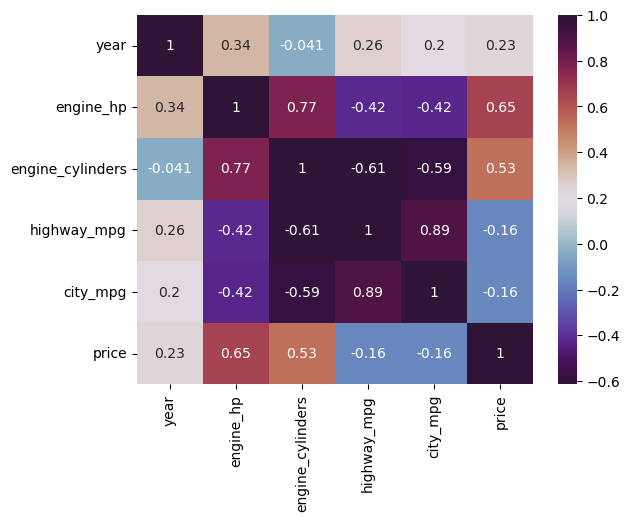

In [39]:
sns.heatmap(corr, annot=True, cmap='twilight_shifted')

In [36]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viri

### Make `price` binary

* Now we need to turn the `price` variable from numeric into a binary format.
* Let's create a variable `above_average` which is `1` if the `price` is above its mean value and `0` otherwise.

In [48]:
above_average = (df['price'] > df['price'].mean()).astype('int')

In [49]:
above_average

0        1
1        1
2        0
3        0
4        0
        ..
11909    1
11910    1
11911    1
11912    1
11913    0
Name: price, Length: 11914, dtype: int64

In [58]:
df['above_average'] = above_average

In [60]:
df.price.mean()

40594.737032063116

In [59]:
df.head()

,make,model,year,engine_hp,engine_cylinders,transmission_type,vehicle_style,highway_mpg,city_mpg,price,above_average
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,Coupe,26,19,46135,1
1,BMW,1 Series,2011,300.0,6.0,MANUAL,Convertible,28,19,40650,1
2,BMW,1 Series,2011,300.0,6.0,MANUAL,Coupe,28,20,36350,0
3,BMW,1 Series,2011,230.0,6.0,MANUAL,Coupe,28,18,29450,0
4,BMW,1 Series,2011,230.0,6.0,MANUAL,Convertible,28,18,34500,0


 Split your data in train/val/test sets with 60%/20%/20% distribution.
* Use Scikit-Learn for that (the `train_test_split` function) and set the seed to `42`.
* Make sure that the target value (`above_average`) is not in your dataframe.

In [82]:
def split_data(df):
    features = ['make',
 'model',
 'year',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'vehicle_style',
 'highway_mpg',
 'city_mpg']
    
    df = df.copy()
    df_train_full, df_test, y_train_full, y_test = train_test_split(df[features], df.above_average, test_size=0.2, random_state=42) 
    df_train, df_val, y_train, y_val = train_test_split(df_train_full, y_train_full, test_size=0.25, random_state=42)

    return df_train, df_val, df_test, y_train, y_val, y_test
    
    

In [83]:
df_train, df_val, df_test, y_train, y_val, y_test = split_data(df)

In [84]:
len(df_train), len(y_train)

(7148, 7148)

In [85]:
len(df_val), len(y_val)

(2383, 2383)

In [86]:
len(df_test), len(y_test)

(2383, 2383)

In [81]:
df_train.head()

,make,model,year,engine_hp,engine_cylinders,transmission_type,vehicle_style,highway_mpg,city_mpg
3972,Mitsubishi,Endeavor,2011,225.0,6.0,AUTOMATIC,4dr SUV,19,15
1997,Kia,Borrego,2009,276.0,6.0,AUTOMATIC,4dr SUV,21,17
5216,Lamborghini,Gallardo,2012,570.0,10.0,MANUAL,Convertible,20,12
2805,Chevrolet,Colorado,2016,200.0,4.0,AUTOMATIC,Crew Cab Pickup,27,20
11369,Pontiac,Vibe,2009,158.0,4.0,AUTOMATIC,4dr Hatchback,26,20


In [87]:
y_train

3972     0
1997     0
5216     1
2805     0
11369    0
        ..
9232     0
5710     0
11306    0
4414     0
10286    0
Name: above_average, Length: 7148, dtype: int64

### Question 3

* Calculate the mutual information score between `above_average` and other categorical variables in our dataset. 
  Use the training set only.
* Round the scores to 2 decimals using `round(score, 2)`.

Which of these variables has the lowest mutual information score?
  
- `make`
- `model`
- `transmission_type`
- `vehicle_style`

In [93]:
from sklearn.metrics import mutual_info_score

In [90]:
categorical = [c for c in df.columns if df[c].dtype == 'object']

In [91]:
categorical

['make', 'model', 'transmission_type', 'vehicle_style']

In [94]:
df_train.head()

,make,model,year,engine_hp,engine_cylinders,transmission_type,vehicle_style,highway_mpg,city_mpg
3972,Mitsubishi,Endeavor,2011,225.0,6.0,AUTOMATIC,4dr SUV,19,15
1997,Kia,Borrego,2009,276.0,6.0,AUTOMATIC,4dr SUV,21,17
5216,Lamborghini,Gallardo,2012,570.0,10.0,MANUAL,Convertible,20,12
2805,Chevrolet,Colorado,2016,200.0,4.0,AUTOMATIC,Crew Cab Pickup,27,20
11369,Pontiac,Vibe,2009,158.0,4.0,AUTOMATIC,4dr Hatchback,26,20


In [96]:
y_train.head()

3972     0
1997     0
5216     1
2805     0
11369    0
Name: above_average, dtype: int64

In [98]:
def mi_above_avg_score(series):
    return mutual_info_score(series, y_train)

In [100]:
mi = df_train[categorical].apply(mi_above_avg_score)
mi.sort_values(ascending=True)

transmission_type    0.020958
vehicle_style        0.084143
make                 0.239769
model                0.462344
dtype: float64

answerL: transmission_type

### Question 4

* Now let's train a logistic regression.
* Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
* Fit the model on the training dataset.
    - To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
    - `model = LogisticRegression(solver='liblinear', C=10, max_iter=1000, random_state=42)`
* Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

What accuracy did you get?

- 0.60
- 0.72
- 0.84
- 0.95

In [102]:
from sklearn.linear_model import LogisticRegression

In [105]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import accuracy_score

In [118]:
# def train_log_reg():

train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')

dv = DictVectorizer(sparse=False)

X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

model = LogisticRegression(solver='liblinear', C=10, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# y_pred = model.predict_proba(X_val)[:, 1] 
# y_pred = (y_pred > 0.5).astype('int')

y_pred = model.predict(X_val)
y_pred
# y_pred = (y_pred > 0.5).astype('int')


val_acc = round(accuracy_score(y_val, y_pred), 2)   
val_acc

0.94

closest answer: 0.95

### Question 5 

* Let's find the least useful feature using the *feature elimination* technique.
* Train a model with all these features (using the same parameters as in Q4).
* Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
* For each feature, calculate the difference between the original accuracy and the accuracy without the feature. 

Which of following feature has the smallest difference?

- `year`
- `engine_hp`
- `transmission_type`
- `city_mpg`

> **Note**: the difference doesn't have to be positive

In [133]:
def train_log_reg(missing_feature, df_train=df_train, df_val=df_val, y_train=y_train, y_val=y_val):
    
    df_train = df_train.copy()
    df_val = df_val.copy()

    if missing_feature:
        df_train = df_train.drop(missing_feature, axis=1)
        df_val = df_val.drop(missing_feature, axis=1)
    
    train_dicts = df_train.to_dict(orient='records')
    val_dicts = df_val.to_dict(orient='records')
    
    dv = DictVectorizer(sparse=False)
    
    X_train = dv.fit_transform(train_dicts)
    X_val = dv.transform(val_dicts)
    
    model = LogisticRegression(solver='liblinear', C=10, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    # y_pred = model.predict_proba(X_val)[:, 1] 
    # y_pred = (y_pred > 0.5).astype('int')
    
    y_pred = model.predict(X_val)
    
    # y_pred = (y_pred > 0.5).astype('int')
    
    
    val_acc = accuracy_score(y_val, y_pred)  
    return val_acc


In [134]:
train_log_reg(None, df_train=df_train, df_val=df_val, y_train=y_train, y_val=y_val)

0.9446076374318086

In [140]:
original_acc = train_log_reg(None, df_train=df_train, df_val=df_val, y_train=y_train, y_val=y_val)
select_features = ['year', 'engine_hp', 'transmission_type', 'city_mpg']
least_diff = float('inf')
least_important = None


for f in select_features:
    new_acc = train_log_reg(f)
    diff = round(abs(original_acc - new_acc), 5)
    
    if diff < least_diff:
        least_important = f
        least_diff = diff
    print(f"excluded_feature: {f} ----> abs_acc_diff: {diff}")
    print()


print(f"The least important feature (of the given options) in terms of differnce in accuracy is {least_important}")
    
    
    

excluded_feature: year ----> abs_acc_diff: 0.00252

excluded_feature: engine_hp ----> abs_acc_diff: 0.02056

excluded_feature: transmission_type ----> abs_acc_diff: 0.0021

excluded_feature: city_mpg ----> abs_acc_diff: 0.01217

The least important feature (of the given options) in terms of differnce in accuracy is transmission_type


of the listed options removing 'transmission_type' appears to make the smallest difference in terms of accuracy.

### Question 6

* For this question, we'll see how to use a linear regression model from Scikit-Learn.
* We'll need to use the original column `price`. Apply the logarithmic transformation to this column.
* Fit the Ridge regression model on the training data with a solver `'sag'`. Set the seed to `42`.
* This model also has a parameter `alpha`. Let's try the following values: `[0, 0.01, 0.1, 1, 10]`.
* Round your RMSE scores to 3 decimal digits.

Which of these alphas leads to the best RMSE on the validation set?

- 0
- 0.01
- 0.1
- 1
- 10

> **Note**: If there are multiple options, select the smallest `alpha`.

In [149]:
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

In [144]:
log_price = np.log1p(df['price'])

In [152]:
def train_ridge(df_train=df_train, df_val=df_val, log_price=log_price, alpha=0.01):
    df_train = df_train.copy()
    df_val = df_val.copy()

    y_train = log_price.iloc[df_train.index]
    y_val = log_price.iloc[df_val.index]
    
    train_dicts = df_train.to_dict(orient='records')
    val_dicts = df_val.to_dict(orient='records')
    
    dv = DictVectorizer(sparse=False)
    
    X_train = dv.fit_transform(train_dicts)
    X_val = dv.transform(val_dicts)
    
    model = Ridge(alpha=alpha, solver='sag', max_iter=1500, random_state=42)
    model.fit(X_train, y_train)
    

    y_pred = model.predict(X_val)
    rmse = round(root_mean_squared_error(y_val, y_pred), 3)
    
      
    return rmse

    

In [153]:
log_price.iloc[df_train.index]

3972     10.422281
1997     10.175269
5216     12.421188
2805     10.126271
11369     9.927009
           ...    
9232     10.536248
5710     10.132056
11306    10.252241
4414      7.601402
10286    10.602145
Name: price, Length: 7148, dtype: float64

In [154]:
for a in [0, 0.01, 0.1, 1, 10]:
    score = train_ridge(df_train=df_train, df_val=df_val, log_price=log_price, alpha=a)
    print(f"alpha: {a} ----> val_rmse: {score}")
    

/Users/isaachurwitz/opt/anaconda3/envs/ml-zoomcamp/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


alpha: 0 ----> val_rmse: 0.477


/Users/isaachurwitz/opt/anaconda3/envs/ml-zoomcamp/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


alpha: 0.01 ----> val_rmse: 0.477


/Users/isaachurwitz/opt/anaconda3/envs/ml-zoomcamp/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


alpha: 0.1 ----> val_rmse: 0.477


/Users/isaachurwitz/opt/anaconda3/envs/ml-zoomcamp/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


alpha: 1 ----> val_rmse: 0.477
alpha: 10 ----> val_rmse: 0.477


/Users/isaachurwitz/opt/anaconda3/envs/ml-zoomcamp/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [120]:
df_train.columns

Index(['make', 'model', 'year', 'engine_hp', 'engine_cylinders',
       'transmission_type', 'vehicle_style', 'highway_mpg', 'city_mpg'],
      dtype='object')